# The Gaia colour–magnitude diagram, by hand

Gaia measured trigonometric parallaxes for over a billion stars. A parallax is
a distance, and a distance turns an *apparent* magnitude into an *absolute*
one — turning a colour–magnitude diagram into a physical
**Hertzsprung–Russell diagram**, where stellar evolution can be read directly.

This notebook reproduces **Fig. 5c** of Gaia Collaboration, Babusiaux et al.
(2018), [A&A 616, A10](https://arxiv.org/abs/1804.09378): the HRD of the
**212,728 stars within 100 pc**, using the paper's own quality selection.

The plan mirrors the server's four tools:

1. get the 100 pc sample (bundled snapshot of the archive query),
2. apply the paper's quality filters — watching the star counts,
3. compute absolute magnitudes from inverted parallaxes,
4. draw the density diagram.

Then the same steps as MCP tools, and the tools as a server.

## 1. The sample

The real query is ADQL against `gaiadr2.gaia_source`:

```sql
SELECT source_id, parallax, parallax_over_error, phot_g_mean_mag, bp_rp, ...
FROM gaiadr2.gaia_source
WHERE parallax >= 10 AND parallax_over_error > 10
```

- `parallax >= 10` mas ⇒ distance < 100 pc (a volume-limited sphere),
- `parallax_over_error > 10` ⇒ distances good to ~10 %. This is what makes
  `d = 1/parallax` acceptable here: for noisy or negative parallaxes,
  inverting is biased or meaningless.
- **No `SELECT TOP N`** — a truncated result is *not* a random sample. (If
  you ever need an unbiased subsample, use Gaia's `random_index` column.)

A snapshot of the full query result ships with this repo, so everything below
works offline. `tools.gaia.query_archive()` runs the live query instead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tools import gaia

data = gaia.load_bundled(min_parallax_mas=10.0, min_parallax_snr=10.0)
print(f"{len(data):,} sources with parallax >= 10 mas and parallax SNR > 10")
print(f"columns: {data.dtype.names}")

439,019 sources with parallax >= 10 mas and parallax SNR > 10
columns: ('source_id', 'l', 'b', 'parallax', 'parallax_over_error', 'phot_g_mean_mag', 'bp_rp', 'phot_bp_rp_excess_factor', 'phot_g_mean_flux_over_error', 'phot_bp_mean_flux_over_error', 'phot_rp_mean_flux_over_error', 'visibility_periods_used', 'astrometric_chi2_al', 'astrometric_n_good_obs_al', 'pmra', 'pmdec', 'radial_velocity', 'variable', 'j_m', 'ks_m')


## 2. Why quality filters — the raw diagram first

Parallax and a G magnitude are enough to compute
$M_G = G + 5\log_{10}(\varpi/\mathrm{mas}) - 10$. Plot the sample *without*
photometric quality cuts and the HRD is there, but smeared: sources whose
BP/RP photometry is contaminated by a neighbour (blends) form a spurious
plume cutting across the diagram, and poor astrometric solutions scatter
everywhere.

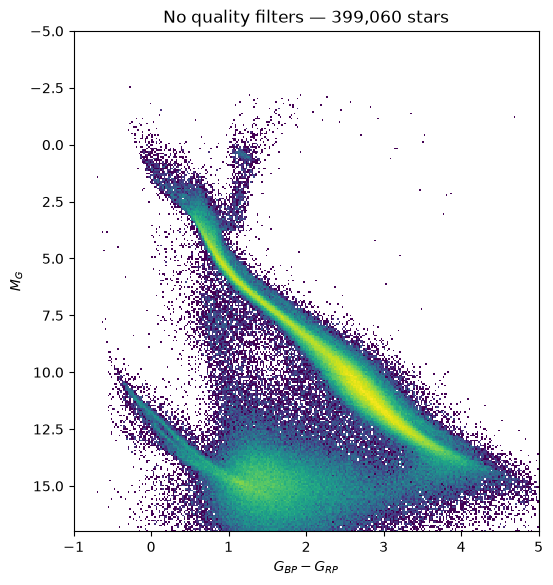

In [2]:
abs_g_raw = data["phot_g_mean_mag"] + 5 * np.log10(data["parallax"]) - 10

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(6, 6.5))
ax.hist2d(data["bp_rp"], abs_g_raw, bins=300,
          range=[[-1, 5], [-5, 17]], norm=LogNorm(), cmap="viridis", cmin=1)
ax.set_ylim(17, -5)
ax.set_xlabel(r"$G_{BP} - G_{RP}$"); ax.set_ylabel(r"$M_G$")
ax.set_title(f"No quality filters — {np.isfinite(data['bp_rp']).sum():,} stars")
plt.show()

## 3. The published quality filters

Babusiaux et al. (2018), Sect. 2.1 — each cut, and why:

| filter | keeps | why |
|---|---|---|
| `phot_g_mean_flux_over_error > 50` | G good to ~2 % | magnitude errors small compared to HRD features |
| `phot_bp/rp_mean_flux_over_error > 20` | colour good to ~5 % | same, for the colour axis |
| `1.0+0.015(B\!-\!R)^2 < E < 1.3+0.06(B\!-\!R)^2` | uncontaminated BP/RP | removes blends — the spurious plume above |
| `visibility_periods_used > 8`, unit weight error < `1.2·max(1, e^{-0.2(G-19.5)})` | good astrometric fits | DR2-era precursor of the `RUWE < 1.4` cut |

Watch the counts: the published Fig. 5c sample is **212,728** stars.

In [3]:
n0 = len(data)
mask = gaia._g_snr(data, 50.0) & ~np.isnan(data["bp_rp"])
print(f"G flux SNR > 50:      {mask.sum():>9,} of {n0:,}")
mask &= gaia._bprp_snr(data, 20.0)
print(f"+ BP/RP flux SNR > 20: {mask.sum():>9,}")
mask &= gaia._excess_factor(data)
print(f"+ excess factor cut:   {mask.sum():>9,}")
mask &= gaia._astrometry(data)
print(f"+ astrometry cut:      {mask.sum():>9,}")

clean = data[mask]
print(f"\npublished Fig. 5c count: {gaia.PUBLISHED_100PC_COUNT:,}")

G flux SNR > 50:        383,149 of 439,019
+ BP/RP flux SNR > 20:   284,639
+ excess factor cut:     251,719
+ astrometry cut:        212,728

published Fig. 5c count: 212,728


## 4. The Hertzsprung–Russell diagram

Absolute magnitude from the inverted parallax (safe *only* because of the
SNR > 10 cut), then a log-scaled density map, bright stars at the top —
axes matched to the published figure.

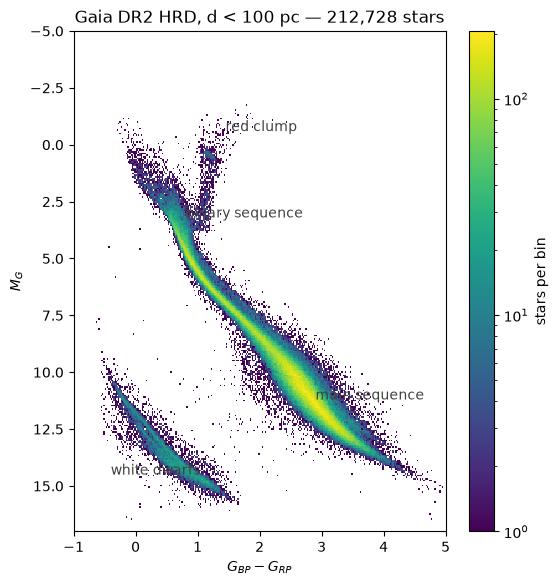

In [4]:
abs_g = clean["phot_g_mean_mag"] + 5 * np.log10(clean["parallax"]) - 10

fig, ax = plt.subplots(figsize=(6, 6.5))
h = ax.hist2d(clean["bp_rp"], abs_g, bins=300,
              range=[[-1, 5], [-5, 17]], norm=LogNorm(), cmap="viridis", cmin=1)
ax.set_ylim(17, -5)
ax.set_xlabel(r"$G_{BP} - G_{RP}$"); ax.set_ylabel(r"$M_G$")
ax.set_title(f"Gaia DR2 HRD, d < 100 pc — {len(clean):,} stars")
fig.colorbar(h[3], ax=ax, label="stars per bin")

ax.annotate("main sequence", (2.9, 11.2), color="0.25")
ax.annotate("binary sequence", (0.8, 3.2), color="0.25")
ax.annotate("red clump", (1.45, -0.6), color="0.25")
ax.annotate("white dwarfs", (-0.4, 14.5), color="0.25")
plt.show()

Everything the mini-project asks for is visible: the **main sequence**, the
**binary sequence** running parallel just above it (unresolved pairs are up
to 0.75 mag brighter), the **red clump** of core-helium-burning giants, and
the **white dwarf sequence** in the lower left.

Two completeness caveats worth stating with any version of this figure:

- the sample is volume-limited in parallax but **magnitude-limited in G** —
  the faint end (late M dwarfs, cool white dwarfs) is incomplete;
- the parallax-SNR cut removes faint red stars preferentially — a *bias*,
  not just a smaller sample.

## 5. The same science as tools

The four functions in `tools/cmd_tools.py` are the pipeline above with file
paths in between: each tool writes a CSV (or PNG) and returns
`{status, files, message, metadata}`. They are plain Python — call them
directly.

In [5]:
from tools import (fetch_gaia_sample, apply_quality_filters,
                   compute_absolute_magnitudes, plot_cmd,
                   compare_distance_shells, plot_kinematics_cmd,
                   plot_variable_stars_cmd, plot_infrared_cmd,
                   plot_sky_map)

OUTPUT_DIR = "output"

r1 = fetch_gaia_sample(OUTPUT_DIR, source="bundled")
print(r1.message)

r2 = apply_quality_filters(r1.files[0], OUTPUT_DIR)
print(r2.message)
for name, n in r2.metadata["removed_by_each_filter_alone"].items():
    print(f"  {name}: removes {n:,} on its own")

r3 = compute_absolute_magnitudes(r2.files[0], OUTPUT_DIR)
print(r3.message)

r4 = plot_cmd(r3.files[0], OUTPUT_DIR)
print(r4.message)

r5 = compare_distance_shells(r2.files[0], OUTPUT_DIR)  # full Fig. 5: 25/50/100 pc
print(r5.message)

for tool in (plot_kinematics_cmd, plot_variable_stars_cmd,
             plot_infrared_cmd, plot_sky_map):
    print(tool(r2.files[0], OUTPUT_DIR).message)

Fetched 439,019 Gaia DR2 sources with parallax >= 10 mas and parallax SNR > 10 from the bundled.


Quality filters kept 212,728 of 439,019 stars (published 100 pc count: 212,728).
  phot_g_snr: removes 55,870 on its own
  phot_bprp_snr: removes 152,502 on its own
  excess_factor: removes 159,033 on its own
  astrometry: removes 195,600 on its own


Computed M_G for 212,728 stars.


Plotted the density CMD of 212,728 stars (published Fig. 5c count: 212,728).


Plotted HRDs for d < 25 pc (3,724 stars), d < 50 pc (29,683 stars), d < 100 pc (212,728 stars).


Velocity-sliced HRDs: 134,733 slow / 34,183 intermediate / 472 halo stars, plus the mean-v_T map.


Marked 1,103 flagged variables on the HRD of 212,728 stars.


Infrared HRD of 200,814 2MASS-matched stars (of 212,728).


Sky map of 212,728 stars in galactic coordinates.


## 6. The tools as an MCP server

The generic wrapper in `mcp_server/` reads `[tool.mcp-server]` from
`pyproject.toml`, imports `tools`, and registers every function in its
`__all__`. Your type hints and docstrings become the schema agents see:

In [6]:
from mcp_server.server import create_server

mcp = create_server()
for tool in await mcp.list_tools():
    required = [n for n, s in tool.inputSchema["properties"].items()
                if n in tool.inputSchema.get("required", [])]
    print(f"{tool.name:28s} required args: {required}")

fetch_gaia_sample            required args: ['output_dir']
apply_quality_filters        required args: ['input_file', 'output_dir']
compute_absolute_magnitudes  required args: ['input_file', 'output_dir']
plot_cmd                     required args: ['input_file', 'output_dir']
compare_distance_shells      required args: ['input_file', 'output_dir']
plot_kinematics_cmd          required args: ['input_file', 'output_dir']
plot_variable_stars_cmd      required args: ['input_file', 'output_dir']
plot_infrared_cmd            required args: ['input_file', 'output_dir']
plot_sky_map                 required args: ['input_file', 'output_dir']


/Users/nesar/anaconda3/envs/spectra-tutorial/lib/python3.12/site-packages/pydantic_settings/sources/utils.py:47: IncompleteFieldDefinitionWarning: Field 'lifespan' has an incomplete definition: its annotation contains an unresolved forward reference, so settings sources may fail to correctly resolve its value. Call `model_rebuild()` on the model where the field is defined, once all the referenced types are defined.
  warnings.warn(


## 7. Run it as a real server

In a terminal (same conda env):

```bash
python -m mcp_server --transport streamable-http --port 8000
```

Clients connect to `http://127.0.0.1:8000/mcp` — for example the LangGraph
multi-agent client in
[`multiagent-client-demo`](https://github.com/HEP-KE/multiagent-client-demo),
which drives this server exactly as it drives `spectra-mcp-server`.

**Questions to think about** (from the mini-project):

- Why is inverting the parallax an unsafe distance estimator in general, and
  why is it acceptable at 100 pc?
- A cut on parallax signal-to-noise improves distances but biases the
  sample. How?
- Your sample is volume-limited in parallax but magnitude-limited in G.
  Which parts of the diagram are incomplete?

## 8. Appendix: a deeper look, with `gaia_tools`

[`jobovy/gaia_tools`](https://github.com/jobovy/gaia_tools) is a veteran
toolbox for Gaia work: an ADQL query helper with a **local result cache**,
catalogue loaders (APOGEE, GALAH, RAVE, LAMOST), cross-matching, and
selection functions. The repository was archived in January 2025 but still
installs and works:

```bash
pip install git+https://github.com/jobovy/gaia_tools
```

We use its `query` module: the same asynchronous archive queries as our
`fetch_gaia_sample` tool, plus caching under `~/.gaia_tools/query_cache`
(kept one week) — re-running this section does not re-download.

The extended query below is the same one the server's
`fetch_gaia_sample` tool now runs (and the bundled snapshot carries all of
its columns) — this appendix builds the figures **by hand** from it, where
section 5 gets them from the tools. Beyond the core columns it carries

- **kinematics** — proper motions, and radial velocities for the bright end,
- **variability** — the DR2 photometric variability flag,
- **2MASS infrared photometry** — a *server-side* cross-match, two `LEFT
  JOIN`s through `gaiadr2.tmass_best_neighbour`.

Together these reproduce the character of the remaining published figures:
the velocity-sliced HRDs (Fig. 7), the infrared HRD (Fig. 6), and the
variable stars on the HRD (Fig. 15).

In [7]:
from gaia_tools import query as gquery

EXTENDED_ADQL = """SELECT g.source_id, g.l, g.b, g.parallax, g.parallax_over_error,
       g.phot_g_mean_mag, g.bp_rp,
       g.phot_bp_rp_excess_factor, g.phot_g_mean_flux_over_error,
       g.phot_bp_mean_flux_over_error, g.phot_rp_mean_flux_over_error,
       g.visibility_periods_used, g.astrometric_chi2_al,
       g.astrometric_n_good_obs_al,
       g.pmra, g.pmdec, g.radial_velocity, g.phot_variable_flag,
       tm.j_m, tm.ks_m
FROM gaiadr2.gaia_source AS g
LEFT OUTER JOIN gaiadr2.tmass_best_neighbour AS bn ON g.source_id = bn.source_id
LEFT OUTER JOIN gaiadr1.tmass_original_valid AS tm ON bn.tmass_oid = tm.tmass_oid
WHERE g.parallax >= 10 AND g.parallax_over_error > 10"""

ext = gquery.query(EXTENDED_ADQL, use_cache=True)
print(f"{len(ext):,} rows, {len(ext.colnames)} columns")

439,020 rows, 20 columns


In [8]:
%matplotlib inline
# (the plot tools above switched matplotlib to the headless Agg backend)

# The astropy Table has masked entries; pull numeric columns as plain arrays
num = {c: np.ma.filled(np.ma.asarray(ext[c]).astype(float), np.nan)
       for c in ext.colnames if c != "phot_variable_flag"}

keep = (gaia._g_snr(num, 50.0) & gaia._bprp_snr(num, 20.0)
        & gaia._excess_factor(num) & gaia._astrometry(num)
        & np.isfinite(num["bp_rp"]))
print(f"after the paper's cuts: {keep.sum():,} stars")

M_G = num["phot_g_mean_mag"][keep] + 5 * np.log10(num["parallax"][keep]) - 10
bp_rp = num["bp_rp"][keep]

after the paper's cuts: 212,728 stars


### 8a. Kinematics select stellar populations (paper Fig. 7)

A tangential velocity needs only what Gaia measures:
$v_T = 4.74\, \mu[\mathrm{mas/yr}] / \varpi[\mathrm{mas}]$ km/s.
Slicing the HRD by $v_T$ separates populations by age and origin: slow
stars are the young thin disc (upper main sequence present), fast stars are
old (upper main sequence gone, subdwarfs sitting blueward/below the main
sequence, halo white dwarfs).

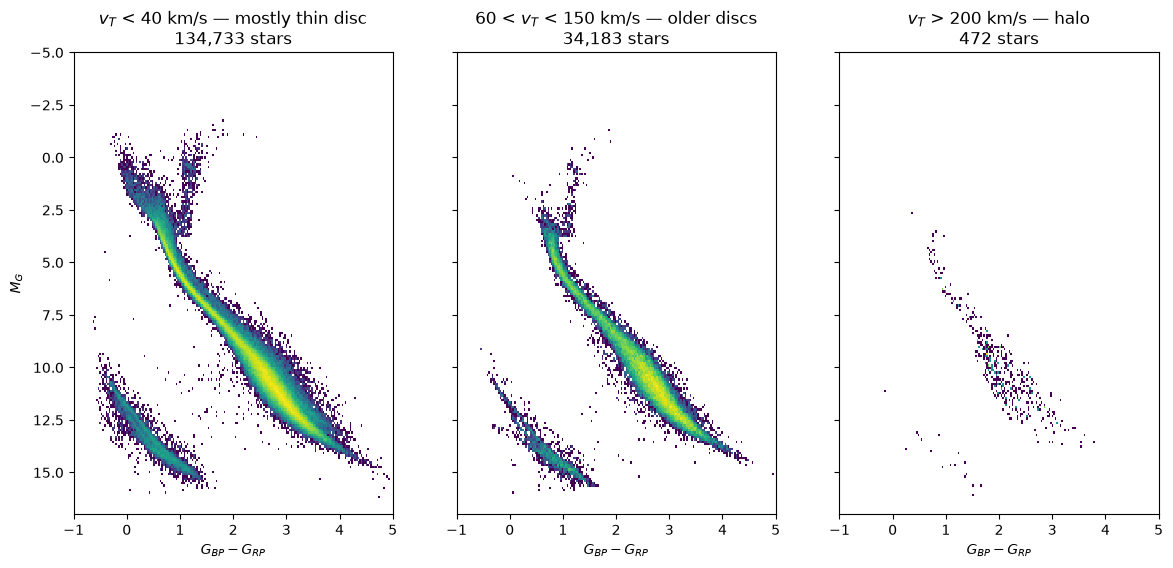

In [9]:
v_tan = 4.74047 * np.hypot(num["pmra"], num["pmdec"])[keep] / num["parallax"][keep]

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
slices = [("$v_T$ < 40 km/s — mostly thin disc", v_tan < 40),
          ("60 < $v_T$ < 150 km/s — older discs", (v_tan > 60) & (v_tan < 150)),
          ("$v_T$ > 200 km/s — halo", v_tan > 200)]
for ax, (title, sel) in zip(axes, slices):
    ax.hist2d(bp_rp[sel], M_G[sel], bins=200, range=[[-1, 5], [-5, 17]],
              norm=LogNorm(), cmap="viridis", cmin=1)
    ax.set_ylim(17, -5)
    ax.set_xlabel(r"$G_{BP} - G_{RP}$")
    ax.set_title(f"{title}\n{sel.sum():,} stars")
axes[0].set_ylabel(r"$M_G$")
plt.show()

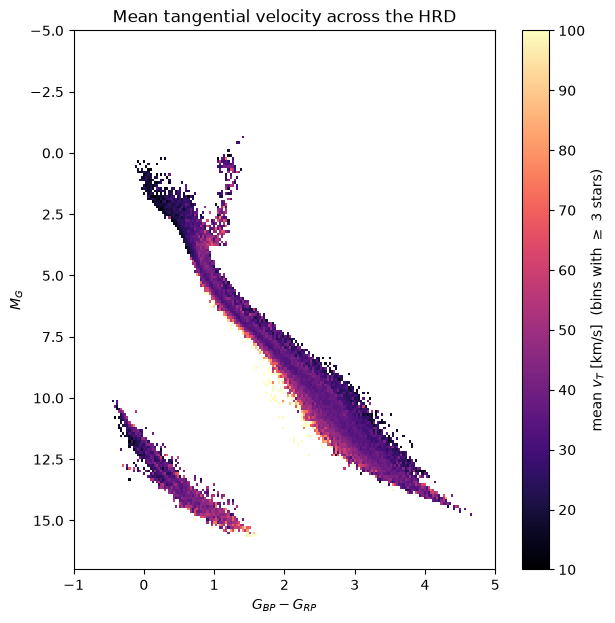

In [10]:
# The same information as one map: mean v_T per CMD bin
H_n, xe, ye = np.histogram2d(bp_rp, M_G, bins=200, range=[[-1, 5], [-5, 17]])
H_v, _, _ = np.histogram2d(bp_rp, M_G, bins=200, range=[[-1, 5], [-5, 17]],
                           weights=v_tan)
mean_v = np.where(H_n >= 3, H_v / np.maximum(H_n, 1), np.nan)

fig, ax = plt.subplots(figsize=(6.8, 7))
im = ax.pcolormesh(xe, ye, mean_v.T, cmap="magma", vmin=10, vmax=100)
ax.set_ylim(17, -5)
ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$M_G$")
ax.set_title("Mean tangential velocity across the HRD")
fig.colorbar(im, ax=ax, label=r"mean $v_T$ [km/s]  (bins with $\geq$ 3 stars)")
plt.show()

### 8b. Variable stars on the HRD (paper Fig. 15)

DR2 flags large-amplitude variables. Within 100 pc these are almost
entirely flaring and spotted M dwarfs on the lower main sequence — and
rare, which is itself the point: the solar neighbourhood contains none of
the bright pulsators (Cepheids, RR Lyrae) that fill that figure in the full
66-million-star sample.

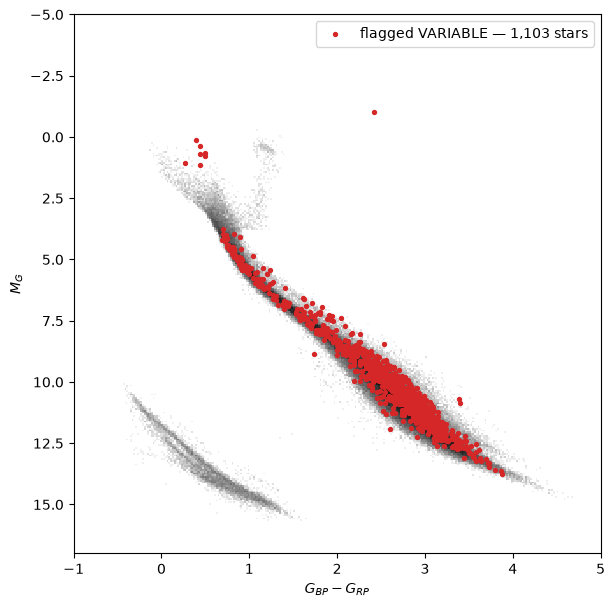

In [11]:
flag = np.asarray(ext["phot_variable_flag"]).astype(str)[keep]
variable = flag == "VARIABLE"

fig, ax = plt.subplots(figsize=(6.8, 7))
ax.hist2d(bp_rp, M_G, bins=300, range=[[-1, 5], [-5, 17]],
          norm=LogNorm(), cmap="Greys", cmin=1)
ax.scatter(bp_rp[variable], M_G[variable], s=8, color="C3",
           label=f"flagged VARIABLE — {variable.sum():,} stars")
ax.set_ylim(17, -5)
ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$M_G$")
ax.legend(loc="upper right")
plt.show()

### 8c. The infrared HRD via the 2MASS cross-match (paper Fig. 6)

The `LEFT JOIN` in the query attached 2MASS $J$ and $K_s$ where a match
exists. In the infrared the main sequence is much less sensitive to
metallicity and the M dwarfs bunch up; white dwarfs are largely too faint
for 2MASS and drop out — a photometric completeness lesson in one panel.

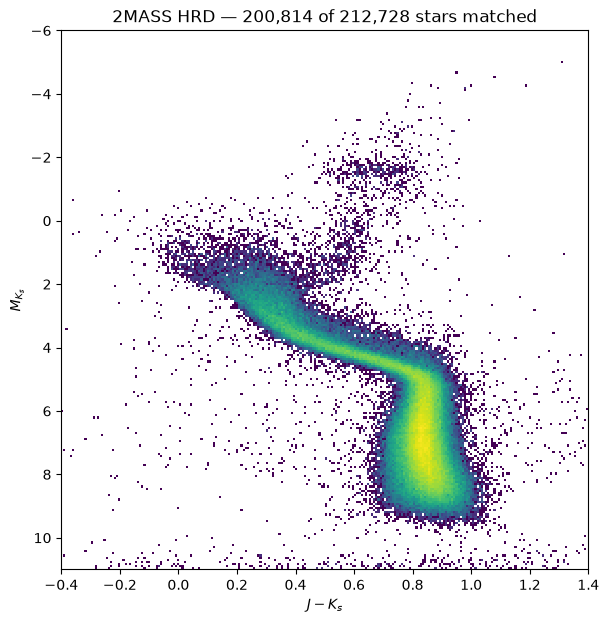

In [12]:
j, ks = num["j_m"][keep], num["ks_m"][keep]
has_ir = np.isfinite(j) & np.isfinite(ks)
M_Ks = ks[has_ir] + 5 * np.log10(num["parallax"][keep][has_ir]) - 10

fig, ax = plt.subplots(figsize=(6.8, 7))
ax.hist2d((j - ks)[has_ir], M_Ks, bins=250, range=[[-0.4, 1.4], [-6, 11]],
          norm=LogNorm(), cmap="viridis", cmin=1)
ax.set_ylim(11, -6)
ax.set_xlabel(r"$J - K_s$")
ax.set_ylabel(r"$M_{K_s}$")
ax.set_title(f"2MASS HRD — {has_ir.sum():,} of {keep.sum():,} stars matched")
plt.show()

### 8d. Where are these stars on the sky?

Within 100 pc the sample should be nearly isotropic — and it almost is.
The overdensity at $l \approx 180°$, $b \approx -22°$ is the **Hyades**,
the nearest open cluster (d ≈ 47 pc); the stark **white holes** are regions Gaia's
scanning law had visited too few times by DR2 — the
`visibility_periods_used > 8` cut empties them entirely, a reminder that
quality filters imprint the survey's geometry on the sample.

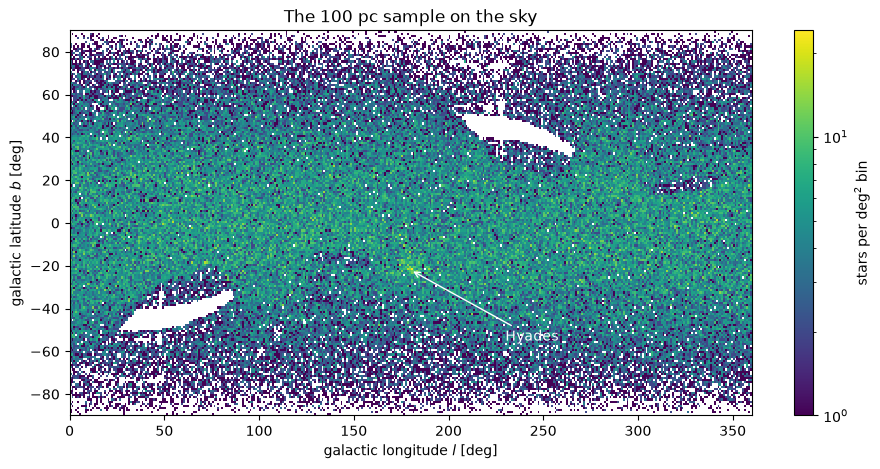

In [13]:
l, b = num["l"][keep], num["b"][keep]

fig, ax = plt.subplots(figsize=(11, 5))
h = ax.hist2d(l, b, bins=[360, 180], range=[[0, 360], [-90, 90]],
              norm=LogNorm(), cmap="viridis")
ax.set_xlabel("galactic longitude $l$ [deg]")
ax.set_ylabel("galactic latitude $b$ [deg]")
ax.set_title("The 100 pc sample on the sky")
ax.annotate("Hyades", (180, -22), xytext=(230, -55), color="white",
            arrowprops=dict(arrowstyle="->", color="white"))
fig.colorbar(h[3], ax=ax, label="stars per deg$^2$ bin")
plt.show()

### What else is in the box

`gaia_tools` also ships catalogue loaders (`gaia_tools.load`: APOGEE,
GALAH, RAVE, LAMOST — spectroscopic surveys to cross-match against Gaia),
a coordinate cross-matcher (`gaia_tools.xmatch`, including CDS-hosted
catalogues), and selection-function machinery (`gaia_tools.select`). Any of
those would make a natural next MCP tool: wrap it as a plain function in
`tools/`, add it to `__all__`, restart the server — the agent picks it up
with no client changes.